In [1]:
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster
import h3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from geopy.distance import geodesic

In [2]:
poi_data = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/poi-point.gpkg')
poi_data.columns = poi_data.columns.str.lower()

In [3]:
poi_data.head()

,name,name_en,name_ru,man_made,leisure,amenity,office,shop,tourism,sport,osm_type,osm_id,geometry
0,Десяточка,None,None,None,None,None,None,supermarket,None,None,node,1000,POINT (37.20753 55.99511)
1,ЕКА,None,None,None,None,fuel,None,None,None,None,node,40889936,POINT (37.53239 55.81613)
2,Газпромнефть,None,None,None,None,fuel,None,None,None,None,node,40901233,POINT (37.50365 55.83637)
3,Лукойл,Lukoil,None,None,None,fuel,None,None,None,None,node,40903852,POINT (37.53582 55.85047)
4,Газпромнефть,None,None,None,None,fuel,None,None,None,None,node,40905170,POINT (37.48176 55.88005)


In [4]:
cols_to_combine = ['man_made', 'leisure', 'amenity', 'office', 'shop', 'tourism', 'sport']
poi_data['amenity'] = poi_data[cols_to_combine].bfill(axis=1).iloc[:, 0]

cols_to_drop = ['man_made', 'leisure', 'office', 'shop', 'tourism', 'sport', 'name', 'name_en', 'name_ru',
                'osm_type', 'osm_id']
poi_data.drop(columns=cols_to_drop, inplace=True)
poi_data.head()

,amenity,geometry
0,supermarket,POINT (37.20753 55.99511)
1,fuel,POINT (37.53239 55.81613)
2,fuel,POINT (37.50365 55.83637)
3,fuel,POINT (37.53582 55.85047)
4,fuel,POINT (37.48176 55.88005)


In [5]:
poi_data['amenity'].unique()

array(['supermarket', 'fuel', 'theatre', 'place_of_worship', 'cafe',
       'police', 'post_office', 'surveillance', 'ferry_terminal',
       'obelisk', 'government', 'museum', 'fast_food', 'restaurant',
       'bar', 'bank', 'pharmacy', 'clock', 'post_box', 'pub', 'parking',
       'attraction', 'convenience', 'works', 'nightclub',
       'parking_entrance', 'cinema', 'clinic', 'viewpoint',
       'social_facility', 'vehicle_inspection', 'marina', 'car_wash',
       'alcohol', 'sports', 'hairdresser', 'mall', 'fountain',
       'arts_centre', 'ticket', 'yes', 'car_parts', 'swimming', 'hostel',
       'doctors', 'outdoor', 'books', 'car_repair', 'car',
       'fitness_centre', 'waste_disposal', 'hotel', 'quay', 'atm',
       'kindergarten', 'sports_centre', 'artwork', 'electronics',
       'clothes', 'bureau_de_change', 'library', 'insurance',
       'picnic_site', 'playground', 'information', 'toilets', 'telephone',
       'doityourself', 'veterinary', 'payment_terminal', 'computer',


In [6]:
food_amenities = ['bakery', 'fast_food', 'food', 'food_court',
 'cafe', 'coffee', 'ice_cream', 'pastry', 'confectionery',
 'seafood', 'frozen_food', 'dairy','butcher', 'beverages', 'bbq', 'restaurant',
 'alcohol', 'wine', 'cheese', 'tea', 'nutrition_supplements', 'milk',
 'health_food', 'beer', 'spices', 'honey','alcohol;bakery', 'atm;ice_cream', 'bakery;pastry;confectionery',
 'bbq;shelter', 'cafeteria', 'chocolate', 'tea;coffee', 'food-related workshops', 'cooking_workshop', 'feeding_place',
    'game_feeding', 'internet_cafe',
]

shops_amenities = ['spices;cosmetics', 'candles', 'spices;butcher', 'supermarket', 'mall','brewing_supplies', 'nuts', 'department_store', 'marketplace', 'online_shop', 'clothes',
 'fashion', 'clothing_accessories', 'shoes', 'electronics', 'computer',
 'electronic_parts', 'hifi', 'mobile_phone', 'mobile_phone_accessories',
 'books', 'newsagent', 'stationery', 'gift', 'gift;video;stationery',
 'jewelry', 'watch', 'watches', 'antiques', 'second_hand', 'vintage',
 'variety_store', 'hardware', 'doityourself', 'garden_centre',
 'furniture', 'houseware', 'bathroom_furnishing', 'kitchen',
 'photo', 'photo_print', 'camera',
 'optician', 'eyewear', 'musical_instrument', 'cosmetics',
 'perfumery', 'boutique', 'florist', 'curtain', 'toys', 'fashion_accessories',
 'bag', 'watch', 'accessories', 'tile', 'tiles', 'tools', 'window_blind',
 'tableware', 'deli', 'appliance', 'carpet', 'gift;florist;second_hand', 'printing_house', 'copyshop', 'ticket', 'agrarian',
 'bag;shoes;accessories', 'beads', 'bijouterie', 'binoculars', 'wool', 'wholesale', 'bowls', 'kiosk', 'duty_free', 'flea_market',
'newspaper', 'electrogoods', 'power_tools', 'plumbing_supplies', 'houseware;clothes', 'houseware;furniture', 'consignment',
'antique', 'gift', 'craft', 'seeds', 'nails', 'lamp', 'hairdresser_supply', 'cashier_service', 'cash_register', 'weighing_scale', 
'repair', 'fishmonger', 'e-cigarette', 'vending_machine', 'clothes;toys', 'electrical', 'electrotools', 'erotic',
'household_linen', 'interior_decoration', 'knives', 'leather', 'lighting', 'military_surplus', 'model', 'paint', 'plumbing',
'printer_ink', 'pyrotechnics', 'pyrotechnics;antiques', 'radiotechnics', 'safety_equipment', 'sewing', 'stamps', 'maps',
'equipment', 'tool_hire', 'cash_register;weighing_scale;repair', 'copyshop;photo', 'copyshop;photo_studio',
'copyshop;shoe_repair;locksmith','dry_cleaning;shoe_repair;clothes_repair;laundry','photo_booth', 'printing',
'metal_repair', 'shoe_repair;clothes_repair', 'shoe_repair;tailor', 'shoe_repair;tailor;copyshop', 'shoemaker',
'tailor;hardware', 'tailor;locksmith', 'tailor;locksmith;shoe_repair', 'tailor;shoe_repair', 'sell', 'nails'

                  ]

car_amenities = ['fuel', 'vehicle_inspection', 'car_wash', 'car_repair', 'car_parts', 'car',
 'car_rental', 'car_sharing', 'driving_school', 'driver_training',
 'parking', 'parking_entrance', 'parking_space',
 'parking_meter', 'vehicle_ramp', 'buggy_parking', 'van_rental', 'tyres',
 'tyres_repair', 'car_wash_equipment', 'car_seats', 'car_repair;bicycle', 'charge_point', 'motor', 'truck', 'transportation',
'tranportation', 'trolley_bay', 'compressed_air'
]

bike_amenities = ['bicycle', 'bicycle_parking', 'bicycle_repair_station', 'bicycle_rental',
 'kick-scooter_parking', 'micro_scooter_parking', 'scooter', 'scooter_rental',
 'motorcycle', 'motorcycle_parking', 'motorcycle_repair', 'bicycle_wash', 'cycling', 'kick-scooter_rental']

public_transport = ['bus_station', 'bus_stop', 'taxi', 'taxi_point',
 'station', 'railway', 'tram_stop', 'metro_station',
 'slipway', 'parking_space', 'loading_dock', 'airport', 'ticket_booth', 'ticket_validator',
'checkpoint', 'post_depot', 'rescue_station'
                             ]

leisure_amenities = ['theatre', 'arts_centre', 'art', 'gallery', 'museum', 'cinema', 'nightclub',
 'bar', 'pub', 'stripclub', 'casino', 'concert_hall', 'karaoke_box', 'piano',
 'theme_park', 'water_park', 'trampoline_park', 'zoo', 'bowling_alley',
 'ice_rink', 'sports_hall', 'escape_game', 'dj', 'hookah_lounge', 'hookah',
 'swingerclub', 'gaming club', 'miniature_golf', 'games', 'lan_gaming_centre', 'dance', 'anime',
  'aquarium', 'attraction', 'auction_house', 'bandstand', 'beach_resort', 'biergarten', 'bleachers', 'beachvolleyball',
'bookmaker', 'lottery', 'gym', 'fitness', 'fitness_centre', 'fitness_station', 'climbing', 'soccer', 'baseball', 'paddle_tennis',
'squash', 'sports_centre', 'stadium', 'arena', 'track', 'training', 'running', 'resort', 'outdoor', 'hammock', 'garden',
'attraction', 'park', 'hobby', 'was:skateboard', 'equestrian', 'horse_riding', 'trail_riding_station',
'chess', 'club', 'fighting', 'fishing', 'fitness;swimming;multi;gymnastics;yoga;exercise',
    'hackerspace', 'horse_racing', 'hunting', 'hunting_stand', 'music', 'party', 'pitch', 'scuba_diving', 'shooting',
'shooting', 'shotball', 'skiing', 'sports', 'summer_camp', 'swimming', 'swimming_pool',
'video_games', 'wakeboarding', 'water_sports', 'carting', 'scene', 'sledding', 'dance', 'brothel', 'guide', 'ski_rental',
'video', 'hairdresser', 'beauty', 'tanning', 'sauna', 'tattoo', 'barber'
                
]

social_amenities = ['police', 'fire_station', 'post_office', 'post_box', 'telephone', 'atm',
 'bank', 'bureau_de_change', 'government', 'townhall', 'courthouse',
 'embassy', 'diplomatic', 'customs', 'municipality', 'public_service', 'social_facility',
 'polling_station', 'registry_office', 'security', 'surveillance', 'CCTV', 'funeral_hall'
 'security_control', 'social_centre', 'ngo', 'association', 'administrative', 'wigs', 'cemetery',
'water_utility', 'notary', 'payment_centre', 'church', 'religion', 'culture', 'community_centre', 'charity', 
'quango', 'political_party', 'public_building', 'official', 'outpost', 'union', 'military', 'geodesist', 'surveyor',
'money_lender', 'money_transfer', 'visa', 'funeral_directors', 'mortuary', 'tomb', 'cash_register; weighing_scale; repair',
'rental', 'security_control', 'wedding', 'funeral_hall'

]

needs_amenities = ['convenience', 'toilets', 'bench', 'lounger', 'collection_point', 'give_box',
 'notice_board', 'recycling', 'watering_place', 'device_charging_station',
 'waste_disposal', 'waste_basket', 'rubbish', 'litter_bin', 'windows', 'wifihotspot', 'box', 'clothes_dryer', 'parcel_locker'
'bridge', 'checkpoint', 'guardhouse', 'water_well', 'wastewater_plant', 'filter', 'pump', 'water_point', 'picnic_table',
'place_of_worship', 'left_luggage', 'cloakroom', 'locker', 'luggage_locker', 'crane', 'table', 'snowmelter', 'bridge',
    'cleaning_equipment', 'doors', 'dressing_room', 'laundry', 'storage_rental',
    'laundry;tailor;locksmith;shoe_repair', 'letter_box', 'mailroom', 'outdoor_seating',
    'parcel_locker', 'planter', 'public_bookcase', 'shower', 'sign', 'sign_plate',
    'smoking_area', 'stroller_parking', 'video_wall', 'street_cabinet', 'frame',
    'utility_pole', 'spring_box'
]

home_amenities = ['hotel', 'hostel', 'guest_house', 'apartment', 'apartment_hotel',
 'student_accommodation', 'dormitory', 'shelter', 'love_hotel', 'motel', 'bed', 'wildlife_hide', 
'camp_pitch', 'chalet', 'hotel_goods', 'reception_desk'
            ]

study_amenity = ['school', 'college', 'university', 'language_school', 'music_school',
 'art_school', 'museum_education', 'educational_institution', 'research_institute',
 'trade_school', 'prep_school', 'adult_education', 'supplementary_education',
 'learning_centers', 'study', 'library', 'mobile_library', 'additional_education', 'aikido', 'gymnastics',
  'boxing', 'kickboxing', 'boxing', 'archery',
 'disc_golf_course', 'karting', 'paintball', 'billiards', 'amusement_arcade',
 'table_tennis', 'arts_school', 'бразильское_джиу-джитсу;грэпплинг;самбо;айкидо;джиу-джитсу;мма;каратэ',
'dancing_school', 'flight_school', 'judo', 'judo;sambo', 'kickboxing;boxing', 'dojo', 'esoteric', 'sambo',
]

children_amenity = ['kindergarten', 'childcare', 'childrens_play_centre', 'toy_library',
 'indoor_play', 'kids_area', 'playground', 'baby_goods']

work_amenity = ['greengrocer', 'photo_lab', 'photo_studio', 'fabric', 'office'
                  'coworking_space', 'coworking_place', 'business_incubator',
 'business', 'company', 'employment_agency', 'job_centre', 'accountants',
 'pawnbroker', 'plumber', 'tailor', 'printer', 'locksmith', 'photographer',
 'reprographics', 'graphic_design', 'engineering',
 'architect', 'consulting', 'property_management',
 'property_maintenance', 'moving_company', 'logistics', 'translation',
 'translator', 'travel_agent', 'travel_agency', 'farm',
 'agency', 'advertising', 'construction_company', 'notary',
 'legal', 'lawyer', 'accountant', 'insurance', 'financial',
 'financial_advisor', 'tax_advisor', 'prosecutor', 'accountant', 'advertising_agency', 'dry_cleaning', 'clothes_repair',
'shoe_repair', 'tailor', 'news_agency', 'electronics_repair', 'collector', 'security_booth', 'office', 'conference_centre',
'coworking', 'coworking_space', 'datacenter', 'provider', 'service', 'event_agency', 'events_venue', 'marketing', 'mass_media',
'media', 'advertising', 'estate_agent', 'research', 'insurance', 'property_management', 'construction_company', 'accountant',
'tax_advisor', 'translator', 'travel_agent', 'camp_site', 'picnic_site', 'security', 'practice', 'guardhouse',
'lost_property_office', 'nesting_site', 'publisher', 'publishing', 'glaziery', 'engineer', 'it', 'trade', 'hvac',
'pest_control', 'telecommunication', 'television', 'telescope', 'studio',
                 ]

infrastructure_amenities = ['ventilation_shaft', 'real_estate', 'clock', 'fountain', 'drinking_water',
                            'drinking_fountain', 'water_point', 'weather_dial', 'water_tower', 'water_works',
                            'water_filter', 'weighbridge', 'storage_tank', 'water_tap',
 'grit_bin', 'payment_terminal', 'ticket_validator', 'manhole', 'silo', 'bunker_silo', 'cellar_entrance',
 'pump', 'pumping_station', 'sewage_works', 'mineshaft', 'pole', 'foundation',
 'smoke_stack', 'mast', 'beacon', 'flagpole', 'cross', 'observation_tower',
 'tower', 'viewpoint', 'monument', 'obelisk', 'artwork', 'plaque', 'statue', 'survey_point', 'adit', 'air_shaft', 'antenna',
'lighthouse', 'chimney', 'ventilation', 'ventilation_schaft', 'power_substation', 'gasometer', 'cctv', 'monitoring_station',
'observatory', 'torii', 'heat_exchange_station', 'electricity', 'energy', 'energy_supplier', 'pipeline', 'gas', 'heating',
'satellite_dish', 'warehouse',
]

pet_amenity = ['veterinary', 'animal_boarding', 'animal_shelter', 'pet', 'pet_grooming', 'animal_breeding', 'beehive',
                 'bird_feeder', 'dovecote',
                'bird_hide', 'birdhouse', 'veterinary_pharmacy', 'dog_park', 'sterilization', 'animal_boarding', 'dog_park',
                ]

other_amenities = ['yes', 'works', 'general', '409', 'fixme', 'unknown', 'vacant', 'metals', 'minerals', 'cairn', 
                  'flare', 'silo', 'bunker_silo', 'cellar_entrance', 'foundation', 'stupa', 'grave', 'grave_yard',
                  'water_tap', 'information', 'opening', 'lean_to', 'firepit', 'fireplace', 'carpet_hanger',
                  'flooring', 'stone', 'tobacco', 'typography', 'upholstery', 'vacuum_cleaner', 'weapons', 
                  'steel_cabinet', 'peak',]

water_amenities = ['quay', 'ferry_terminal', 'marina', 'pier', 'boat', 'boat_rental', 'yacht_club']

health_amenity = ['hospital', 'clinic', 'clinic;doctors', 'doctors', 'dentist', 'pharmacy',
 'chemist', 'medical', 'medical_supply', 'drugstore', 'optician', 'eyewear',
 'hearing_aids', 'physiotherapist', 'sanatorium', 'nursing_home',
 'rehabilitation', 'orthopedics', 'orthopaedist', 'herbalist', 'cosmetics;perfumery', 'spa', 'tanning_salon',
'massage', 'physician', 'pharmacy', 'optics', 'orthopedic', 'multi', 'massage', 'massage_parlour',
                   ]

In [7]:
# Фильтрация данных
poi_data['category'] = 'other_amenities'  # Установка категории по умолчанию
poi_data.loc[poi_data['amenity'].isin(food_amenities), 'category'] = 'food_amenities'
poi_data.loc[poi_data['amenity'].isin(shops_amenities), 'category'] = 'shops_amenities'
poi_data.loc[poi_data['amenity'].isin(car_amenities), 'category'] = 'car_amenities'
poi_data.loc[poi_data['amenity'].isin(bike_amenities), 'category'] = 'bike_amenities'
poi_data.loc[poi_data['amenity'].isin(public_transport), 'category'] = 'public_transport'
poi_data.loc[poi_data['amenity'].isin(leisure_amenities), 'category'] = 'leisure_amenities'
poi_data.loc[poi_data['amenity'].isin(social_amenities), 'category'] = 'social_amenities'
poi_data.loc[poi_data['amenity'].isin(needs_amenities), 'category'] = 'needs_amenities'
poi_data.loc[poi_data['amenity'].isin(water_amenities), 'category'] = 'water_amenities'
poi_data.loc[poi_data['amenity'].isin(home_amenities), 'category'] = 'home_amenities'
poi_data.loc[poi_data['amenity'].isin(study_amenity), 'category'] = 'study_amenity'
poi_data.loc[poi_data['amenity'].isin(children_amenity), 'category'] = 'children_amenity'
poi_data.loc[poi_data['amenity'].isin(work_amenity), 'category'] = 'work_amenity'
poi_data.loc[poi_data['amenity'].isin(health_amenity), 'category'] = 'health_amenity'
poi_data.loc[poi_data['amenity'].isin(infrastructure_amenities), 'category'] = 'infrastructure_amenities'
poi_data.loc[poi_data['amenity'].isin(pet_amenity), 'category'] = 'pet_amenity'

In [8]:
poi_data['category'].unique()

array(['shops_amenities', 'car_amenities', 'leisure_amenities',
       'needs_amenities', 'food_amenities', 'social_amenities',
       'water_amenities', 'infrastructure_amenities', 'health_amenity',
       'other_amenities', 'home_amenities', 'children_amenity',
       'study_amenity', 'work_amenity', 'pet_amenity', 'public_transport',
       'bike_amenities'], dtype=object)

In [9]:
import geopandas as gpd

# Добавляем столбцы в df с нулями
categories = ['shops_amenities', 'car_amenities', 'leisure_amenities',
       'needs_amenities', 'food_amenities', 'social_amenities',
       'water_amenities', 'infrastructure_amenities', 'health_amenity',
       'other_amenities', 'home_amenities',
       'children_amenity', 'study_amenity', 'work_amenity', 'pet_amenity',
       'public_transport', 'bike_amenities']

# Функция для определения, к какой H3-ячейке относится объект POI
def get_h3_index(point, resolution=8):
    return h3.latlng_to_cell(point.y, point.x, resolution)

# Добавляем колонку с H3-ячейками в poi_data
poi_data['h3_index'] = poi_data['geometry'].apply(get_h3_index)

# Группируем по H3-ячейкам и категориям, подсчитываем количество объектов
poi_counts = poi_data.groupby(['h3_index', 'category']).size().reset_index(name='count')

# Разворачиваем таблицу: категории становятся столбцами, h3_index остаётся индексом
poi_pivot = poi_counts.pivot_table(index='h3_index', columns='category', values='count', fill_value=0)

# Сбрасываем индекс, чтобы h3_index снова стал столбцом
poi_pivot.reset_index(inplace=True)

# Убедимся, что category не является заголовком столбцов
poi_pivot.columns.name = None  # Убираем имя столбцов, если оно есть

In [10]:
poi_pivot

,h3_index,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,leisure_amenities,needs_amenities,other_amenities,pet_amenity,public_transport,shops_amenities,social_amenities,study_amenity,water_amenities,work_amenity
0,88118180c3fffff,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,88118182d3fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,88118182d7fffff,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,881181840bfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,8811818447fffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264,8811aa7b67fffff,4.0,7.0,5.0,12.0,3.0,0.0,2.0,3.0,11.0,1.0,0.0,0.0,9.0,5.0,0.0,0.0,0.0
2265,8811aa7b69fffff,1.0,2.0,0.0,2.0,8.0,1.0,0.0,3.0,9.0,0.0,1.0,0.0,10.0,13.0,0.0,0.0,2.0
2266,8811aa7b6bfffff,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,3.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
2267,8811aa7b6dfffff,0.0,4.0,2.0,4.0,11.0,0.0,4.0,2.0,8.0,1.0,0.0,0.0,14.0,9.0,1.0,0.0,3.0


In [11]:
import h3
import folium
import pandas as pd
from shapely.geometry import Polygon

# Координаты центра москвы
moscow_lat, moscow_lng = 55.7522, 37.6156
resolution = 8  # Уровень разрешения H3

# Получаем H3 индекс центральной точки
central_hex = h3.latlng_to_cell(moscow_lat, moscow_lng, resolution)

# Получаем все шестиугольники в радиусе
h3_hexes = h3.grid_disk(central_hex, k=140)

# Список для хранения данных
data = []

# Создаем карту
m = folium.Map(location=[moscow_lat, moscow_lng], zoom_start=10)

# Визуализируем шестиугольники
for hex_id in h3_hexes:
    # Получаем границы гексагона
    hex_boundary = h3.cell_to_boundary(hex_id)
    
    # Создаем полигон для Folium
    folium.Polygon(
        locations=hex_boundary,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.2,
        weight=1
    ).add_to(m)

# Визуализируем шестиугольники и создаем датасет
for hex in h3_hexes:
    hex_boundary = h3.cell_to_boundary(hex)
    # Сохраняем координаты многоугольника в формате списка (широта, долгота)
    for lat, lng in hex_boundary:
        data.append({'latitude': lat, 'longitude': lng, 'h3_index': hex})

# Создаем Pandas DataFrame
df = pd.DataFrame(data)

df

,latitude,longitude,h3_index
0,55.751249,37.601624,8811aa7aabfffff
1,55.747323,37.606036,8811aa7aabfffff
2,55.747789,37.613942,8811aa7aabfffff
3,55.752182,37.617437,8811aa7aabfffff
4,55.756108,37.613026,8811aa7aabfffff
...,...,...,...
355321,56.215840,35.874161,8811ae38abfffff
355322,56.216428,35.882020,8811ae38abfffff
355323,56.220836,35.885318,8811ae38abfffff
355324,56.224658,35.880756,8811ae38abfffff


In [12]:
# Объединяем df и poi_pivot по h3_index
df = df.merge(poi_pivot, on='h3_index', how='left')

# Заполняем пропущенные значения нулями, если в какой-то клетке H3 нет объектов
df.fillna(0, inplace=True)

In [13]:
df

,latitude,longitude,h3_index,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,leisure_amenities,needs_amenities,other_amenities,pet_amenity,public_transport,shops_amenities,social_amenities,study_amenity,water_amenities,work_amenity
0,55.751249,37.601624,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,29.0,172.0,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0
1,55.747323,37.606036,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,29.0,172.0,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0
2,55.747789,37.613942,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,29.0,172.0,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0
3,55.752182,37.617437,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,29.0,172.0,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0
4,55.756108,37.613026,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,29.0,172.0,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355321,56.215840,35.874161,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
355322,56.216428,35.882020,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
355323,56.220836,35.885318,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
355324,56.224658,35.880756,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
parking_data = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/parking-polygon.gpkg')
parking_data.columns = parking_data.columns.str.lower()

In [15]:
import geopandas as gpd
import pandas as pd
import h3
from shapely.geometry import Polygon

# Преобразуем H3 индексы в полигоны
df['geometry'] = df['h3_index'].apply(lambda x: Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(x)]))

df = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

parking_data = parking_data.explode(ignore_index=True)  # Разделение MultiPolygon на Polygon

# Преобразуем парковочные данные в ту же систему координат
df = df.to_crs("EPSG:3857")
parking_data = parking_data.to_crs(df.crs)

invalid_parking_data = parking_data[~parking_data.is_valid]
invalid_df = df[~df.is_valid]
parking_data['geometry'] = parking_data['geometry'].apply(lambda x: x.buffer(0) if not x.is_valid else x)

# Добавляем колонку с площадью парковок
parking_data['area'] = parking_data['geometry'].area   # Площадь в квадратных метрах

# Находим пересечение парковок с H3 ячейками
parking_intersection = gpd.overlay(parking_data, df, how='intersection')

# Группируем и суммируем площадь парковок по h3_index
parking_sums = parking_intersection.groupby('h3_index')['area'].sum().reset_index()

# Объединяем с df, если в h3_index нет парковки — заполняем 0
df = df.merge(parking_sums, on='h3_index', how='left').fillna({'area': 0})

# Переименуем колонку в parking_area (м²)
df.rename(columns={'area': 'parking_area'}, inplace=True)
df = df.to_crs("EPSG:4326")

In [16]:
df

,latitude,longitude,h3_index,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,...,other_amenities,pet_amenity,public_transport,shops_amenities,social_amenities,study_amenity,water_amenities,work_amenity,geometry,parking_area
0,55.751249,37.601624,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073
1,55.747323,37.606036,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073
2,55.747789,37.613942,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073
3,55.752182,37.617437,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073
4,55.756108,37.613026,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,22.0,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355321,56.215840,35.874161,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000
355322,56.216428,35.882020,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000
355323,56.220836,35.885318,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000
355324,56.224658,35.880756,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000


In [17]:
LONDON_AVERAGE_ANNUAL_DAILY_FLOW_PATH = "//Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/data/traffic_data/london_data/dft_aadf_region_id_6.csv"
daily_flow_london = pd.read_csv(LONDON_AVERAGE_ANNUAL_DAILY_FLOW_PATH).dropna(subset=['latitude', 'longitude'])
traffic_mean_london = daily_flow_london['all_motor_vehicles'].mean()

In [18]:
# заполняем траффик средним по Лондону
df['traffic_count'] = traffic_mean_london

In [19]:
df

,latitude,longitude,h3_index,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,...,pet_amenity,public_transport,shops_amenities,social_amenities,study_amenity,water_amenities,work_amenity,geometry,parking_area,traffic_count
0,55.751249,37.601624,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305
1,55.747323,37.606036,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305
2,55.747789,37.613942,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305
3,55.752182,37.617437,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305
4,55.756108,37.613026,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,0.0,2.0,15.0,21.0,5.0,0.0,10.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355321,56.215840,35.874161,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000,23432.645305
355322,56.216428,35.882020,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000,23432.645305
355323,56.220836,35.885318,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000,23432.645305
355324,56.224658,35.880756,8811ae38abfffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((35.8696 56.21966, 35.87416 56.21584,...",0.000000,23432.645305


In [20]:
building_data = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/building-point.gpkg')
building_data.columns = building_data.columns.str.lower()

In [21]:
building_data.head()

,building,addr_city,a_strt,a_sbrb,a_hsnmbr,a_place,a_pstcd,b_levels,name,name_en,name_ru,osm_type,osm_id,geometry
0,kiosk,None,None,None,None,None,None,None,None,None,None,node,595448550,POINT (37.66605 55.87072)
1,yes,None,None,None,None,None,None,None,None,None,None,node,607989336,POINT (37.73575 55.64488)
2,yes,None,Подъёмная улица,None,12А с11,None,None,None,None,None,None,node,623415761,POINT (37.71023 55.74112)
3,bunker,None,None,None,None,None,None,None,бомбоубежище,None,None,node,638742556,POINT (37.16979 55.99401)
4,yes,None,None,None,None,None,None,None,Energy,None,None,node,727537366,POINT (36.93079 55.47161)


In [22]:
building_data['building'].unique()

array(['kiosk', 'yes', 'bunker', 'service', 'garage', 'church', 'house',
       'ventilation_kiosk', 'public', 'chapel', 'hut', 'office', 'shed',
       'garages', 'industrial', 'guardhouse', 'construction', 'gazebo',
       'font', 'roof', 'school', 'storage_tank', 'sty', 'dovecote',
       'residential', 'ruins', 'tree_house', 'cabin', 'apartments',
       'commercial', 'toilets', 'retail', 'transformer', 'gatehouse'],
      dtype=object)

In [23]:
def get_h3_index(point, resolution=8):
    return h3.latlng_to_cell(point.y, point.x, resolution)

building_data['h3_index'] = building_data['geometry'].apply(get_h3_index)

In [24]:
building_counts = building_data.groupby(["h3_index", "building"]).size().unstack(fill_value=0).reset_index()

In [25]:
for b_type in building_data["building"].unique():
    if b_type not in building_counts.columns:
        building_counts[b_type] = 0

In [26]:
df = df.merge(building_counts, on="h3_index", how="left")
df[building_data['building'].unique()] = df[building_data['building'].unique()].fillna(0)

In [27]:
df['shops_amenities'] += df['kiosk']
df['other_amenities'] += df['yes']
df['infrastructure_amenities'] += df['bunker']
df['work_amenity'] += df['work_amenity']
df['car_amenities'] += df['garage']
df['social_amenities'] += df['church']
df['home_amenities'] += df['house']
df['infrastructure_amenities'] += df['ventilation_kiosk']
df['social_amenities'] += df['public']
df['infrastructure_amenities'] += df['chapel']
df['home_amenities'] += df['hut']
df['work_amenity'] += df['office']
df['infrastructure_amenities'] += df['shed']
df['car_amenities'] += df['garages']
df['work_amenity'] += df['industrial']
df['infrastructure_amenities'] += df['guardhouse']
df['infrastructure_amenities'] += df['construction']
df['needs_amenities'] += df['gazebo']
df['leisure_amenities'] += df['font']
df['other_amenities'] += df['roof']
df['study_amenity'] += df['school']
df['infrastructure_amenities'] += df['storage_tank']
df['pet_amenity'] += df['sty']
df['pet_amenity'] += df['dovecote']
df['home_amenities'] += df['residential']
df['other_amenities'] += df['ruins']
df['home_amenities'] += df['tree_house']
df['leisure_amenities'] += df['cabin']
df['home_amenities'] += df['apartments']
df['work_amenity'] += df['commercial']
df['needs_amenities'] += df['toilets']
df['work_amenity'] += df['retail']
df['infrastructure_amenities'] += df['transformer']
df['home_amenities'] += df['gatehouse']

df = df.drop(columns=building_data['building'].unique())

In [28]:
df.columns

Index(['latitude', 'longitude', 'h3_index', 'bike_amenities', 'car_amenities',
       'children_amenity', 'food_amenities', 'health_amenity',
       'home_amenities', 'infrastructure_amenities', 'leisure_amenities',
       'needs_amenities', 'other_amenities', 'pet_amenity', 'public_transport',
       'shops_amenities', 'social_amenities', 'study_amenity',
       'water_amenities', 'work_amenity', 'geometry', 'parking_area',
       'traffic_count'],
      dtype='object')

In [29]:
aerialway_point_data = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/aerialway-point.gpkg')
aerialway_point_data.columns = aerialway_point_data.columns.str.lower()
def get_h3_index(point, resolution=8):
    return h3.latlng_to_cell(point.y, point.x, resolution)

aerialway_point_data['h3_index'] = aerialway_point_data['geometry'].apply(get_h3_index)
aerialway_counts = aerialway_point_data.groupby("h3_index").size().reset_index(name="count")
aerialway_counts

,h3_index,count
0,8811aa4481fffff,1
1,8811aa4525fffff,1
2,8811aa4d0bfffff,2
3,8811aa4e19fffff,2
4,8811aa4e1bfffff,1
5,8811aa6355fffff,2
6,8811aa7195fffff,1
7,8811aa71b3fffff,2
8,8811aa71bbfffff,4
9,8811aa7849fffff,2


In [30]:
df = df.merge(aerialway_counts, on='h3_index', how='left')

df['leisure_amenities'] = df['leisure_amenities'] + df['count'].fillna(0)

df = df.drop(columns=['count'])

In [31]:
high_way_crossing_point_data = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/highway-crossing-point.gpkg')
high_way_crossing_point_data.columns = high_way_crossing_point_data.columns.str.lower()
high_way_crossing_point_data['h3_index'] = high_way_crossing_point_data['geometry'].apply(get_h3_index)
high_way_counts = high_way_crossing_point_data.groupby("h3_index").size().reset_index(name="count")
high_way_counts = high_way_counts.rename(columns={'count': 'highway'})
df = df.merge(high_way_counts, on="h3_index", how="left")
df['highway'] = df['highway'].fillna(0)

In [32]:
df.head()

,latitude,longitude,h3_index,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,...,public_transport,shops_amenities,social_amenities,study_amenity,water_amenities,work_amenity,geometry,parking_area,traffic_count,highway
0,55.751249,37.601624,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,2.0,16.0,21.0,5.0,0.0,20.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305,46.0
1,55.747323,37.606036,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,2.0,16.0,21.0,5.0,0.0,20.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305,46.0
2,55.747789,37.613942,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,2.0,16.0,21.0,5.0,0.0,20.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305,46.0
3,55.752182,37.617437,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,2.0,16.0,21.0,5.0,0.0,20.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305,46.0
4,55.756108,37.613026,8811aa7aabfffff,10.0,8.0,0.0,39.0,4.0,11.0,72.0,...,2.0,16.0,21.0,5.0,0.0,20.0,"POLYGON ((37.60162 55.75125, 37.60604 55.74732...",172405.525073,23432.645305,46.0


In [33]:
port_point = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/port-point.gpkg')
port_point.columns = port_point.columns.str.lower()
port_point['h3_index'] = port_point['geometry'].apply(get_h3_index)
port_counts = port_point.groupby("h3_index").size().reset_index(name="count")

In [34]:
df = df.merge(port_counts, on='h3_index', how='left')
df['water_amenities'] = df['water_amenities'] + df['count'].fillna(0)
df = df.drop(columns=['count'])

In [35]:
public_transport_point = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/public-transport-point.gpkg')
public_transport_point.columns = public_transport_point.columns.str.lower()
public_transport_point.columns = public_transport_point.columns.str.lower()
public_transport_point['h3_index'] = public_transport_point['geometry'].apply(get_h3_index)
public_transport_counts = public_transport_point.groupby("h3_index").size().reset_index(name="count")

In [36]:
df = df.merge(public_transport_counts, on='h3_index', how='left')
df['public_transport'] = df['public_transport'] + df['count'].fillna(0)
df = df.drop(columns=['count'])

In [37]:
railway_station_point = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/railway-station-point.gpkg')
railway_station_point.columns = railway_station_point.columns.str.lower()
railway_station_point['h3_index'] = railway_station_point['geometry'].apply(get_h3_index)
railway_counts = railway_station_point.groupby("h3_index").size().reset_index(name="count")

In [38]:
df = df.merge(railway_counts, on='h3_index', how='left')
df['public_transport'] = df['public_transport'] + df['count'].fillna(0)
df = df.drop(columns=['count'])

In [39]:
subway_entrance_point = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/subway-entrance-point.gpkg')
subway_entrance_point.columns = subway_entrance_point.columns.str.lower()
subway_entrance_point['h3_index'] = subway_entrance_point['geometry'].apply(get_h3_index)
subway_counts = subway_entrance_point.groupby("h3_index").size().reset_index(name="count")

In [40]:
df = df.merge(subway_counts, on='h3_index', how='left')
df['public_transport'] = df['public_transport'] + df['count'].fillna(0)
df = df.drop(columns=['count'])

In [41]:
power_line = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/power-line.gpkg')
power_line.columns = power_line.columns.str.lower()

In [42]:
power_line

,power,voltage,name,osm_type,osm_id,geometry
0,line,110000,None,way,27752299,"LINESTRING (37.43671 55.84078, 37.43642 55.840..."
1,line,500000,None,way,28882759,"LINESTRING (37.62735 55.57698, 37.62712 55.576..."
2,line,220000,None,way,31645653,"LINESTRING (37.38266 55.84589, 37.38304 55.845..."
3,line,220000,ВЛ Жулебино-Восточная,way,32666712,"LINESTRING (37.83445 55.69726, 37.83468 55.69702)"
4,line,220000,None,way,33889399,"LINESTRING (37.58734 55.64168, 37.58857 55.642..."
...,...,...,...,...,...,...
1714,cable,400,None,way,1262135645,"LINESTRING (37.6787 55.57603, 37.67859 55.5761..."
1715,cable,400,None,way,1262135646,"LINESTRING (37.68065 55.57648, 37.68048 55.576..."
1716,cable,400,None,way,1262135649,"LINESTRING (37.67926 55.57595, 37.67917 55.575..."
1717,line,220000,None,way,1267025203,"LINESTRING (37.59628 55.4891, 37.59354 55.4902..."


In [43]:
def get_h3_cells(geometry, resolution):
    h3_cells = set()
    if geometry.geom_type == "LineString":  
        for point in geometry.coords:
            h3_cells.add(h3.latlng_to_cell(point[1], point[0], resolution))
    elif geometry.geom_type == "MultiLineString":  
        for line in geometry.geoms:
            for point in line.coords:
                h3_cells.add(h3.latlng_to_cell(point[1], point[0], resolution))
    return list(h3_cells)

In [44]:
power_line["h3_index"] = power_line["geometry"].apply(lambda geom: get_h3_cells(geom, 8))
power_line_exploded = power_line.explode("h3_index")
power_line_exploded["voltage"] = pd.to_numeric(power_line_exploded["voltage"], errors="coerce")
power_voltage = power_line_exploded.groupby("h3_index")["voltage"].max().reset_index()
df = df.merge(power_voltage, on="h3_index", how="left").fillna(0)

In [45]:
power_point_data = gpd.read_file('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/data/power-point.gpkg')
power_point_data.columns = power_point_data.columns.str.lower()
power_point_data['h3_index'] = power_point_data['geometry'].apply(get_h3_index)
power_point_counts = power_point_data.groupby("h3_index").size().reset_index(name="сharger_number")

In [46]:
df = df.merge(power_point_counts, on='h3_index', how='left').fillna(0)
df["has_charging_station"] = 0
df.loc[df["сharger_number"] >= 1, "has_charging_station"] = 1

In [47]:
df = df.groupby('h3_index', as_index=False).agg({
    'latitude': 'mean',
    'longitude': 'mean',
    **{col: 'first' for col in df.columns if col not in ['latitude', 'longitude', 'h3_index']}
})

In [48]:
moscow_center = (55.7522, 37.6156)

def calculate_distance(lat, lon):
    return geodesic((lat, lon), moscow_center).km

df["distance_to_center"] = df.apply(lambda row: calculate_distance(row["latitude"], row["longitude"]), axis=1)

In [49]:
df = df.drop(columns=['geometry'])

In [50]:
df.shape

(59221, 27)

In [51]:
exclude_columns = ['h3_index', 'latitude', 'longitude', 'distance_to_center', 'traffic_count']
columns_to_check = [col for col in df.columns if col not in exclude_columns]
zero_rows_count = (df[columns_to_check] == 0).all(axis=1).sum()
zero_rows_count

56432

In [52]:
mask = (df[columns_to_check] == 0).all(axis=1)
df = df[~mask]
df.reset_index(drop=True, inplace=True)

In [53]:
df

,h3_index,latitude,longitude,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,...,study_amenity,water_amenities,work_amenity,parking_area,traffic_count,highway,voltage,сharger_number,has_charging_station,distance_to_center
0,88118180c3fffff,55.226721,37.301653,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,0.0,0,61.777085
1,88118180d3fffff,55.244763,37.323087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,0.0,0,59.441911
2,8811818287fffff,55.240533,37.253017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,0.0,0,61.401518
3,88118182d1fffff,55.264058,37.226736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,0.0,0,59.641802
4,88118182d3fffff,55.268927,37.237926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,0.0,0,58.857629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2784,8811aacd9dfffff,55.735759,36.944708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,5.0,1,42.174654
2785,8811aacdbbfffff,55.728986,36.969308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,1.0,1,40.675667
2786,8811aacdd1fffff,55.742526,36.920106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,12.0,1,43.689553
2787,8811aacdd7fffff,55.739144,36.932407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,23432.645305,0.0,0.0,5.0,1,42.930222


In [54]:
df.to_csv('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/final_datasets/dataset_moscow.csv', index=False)

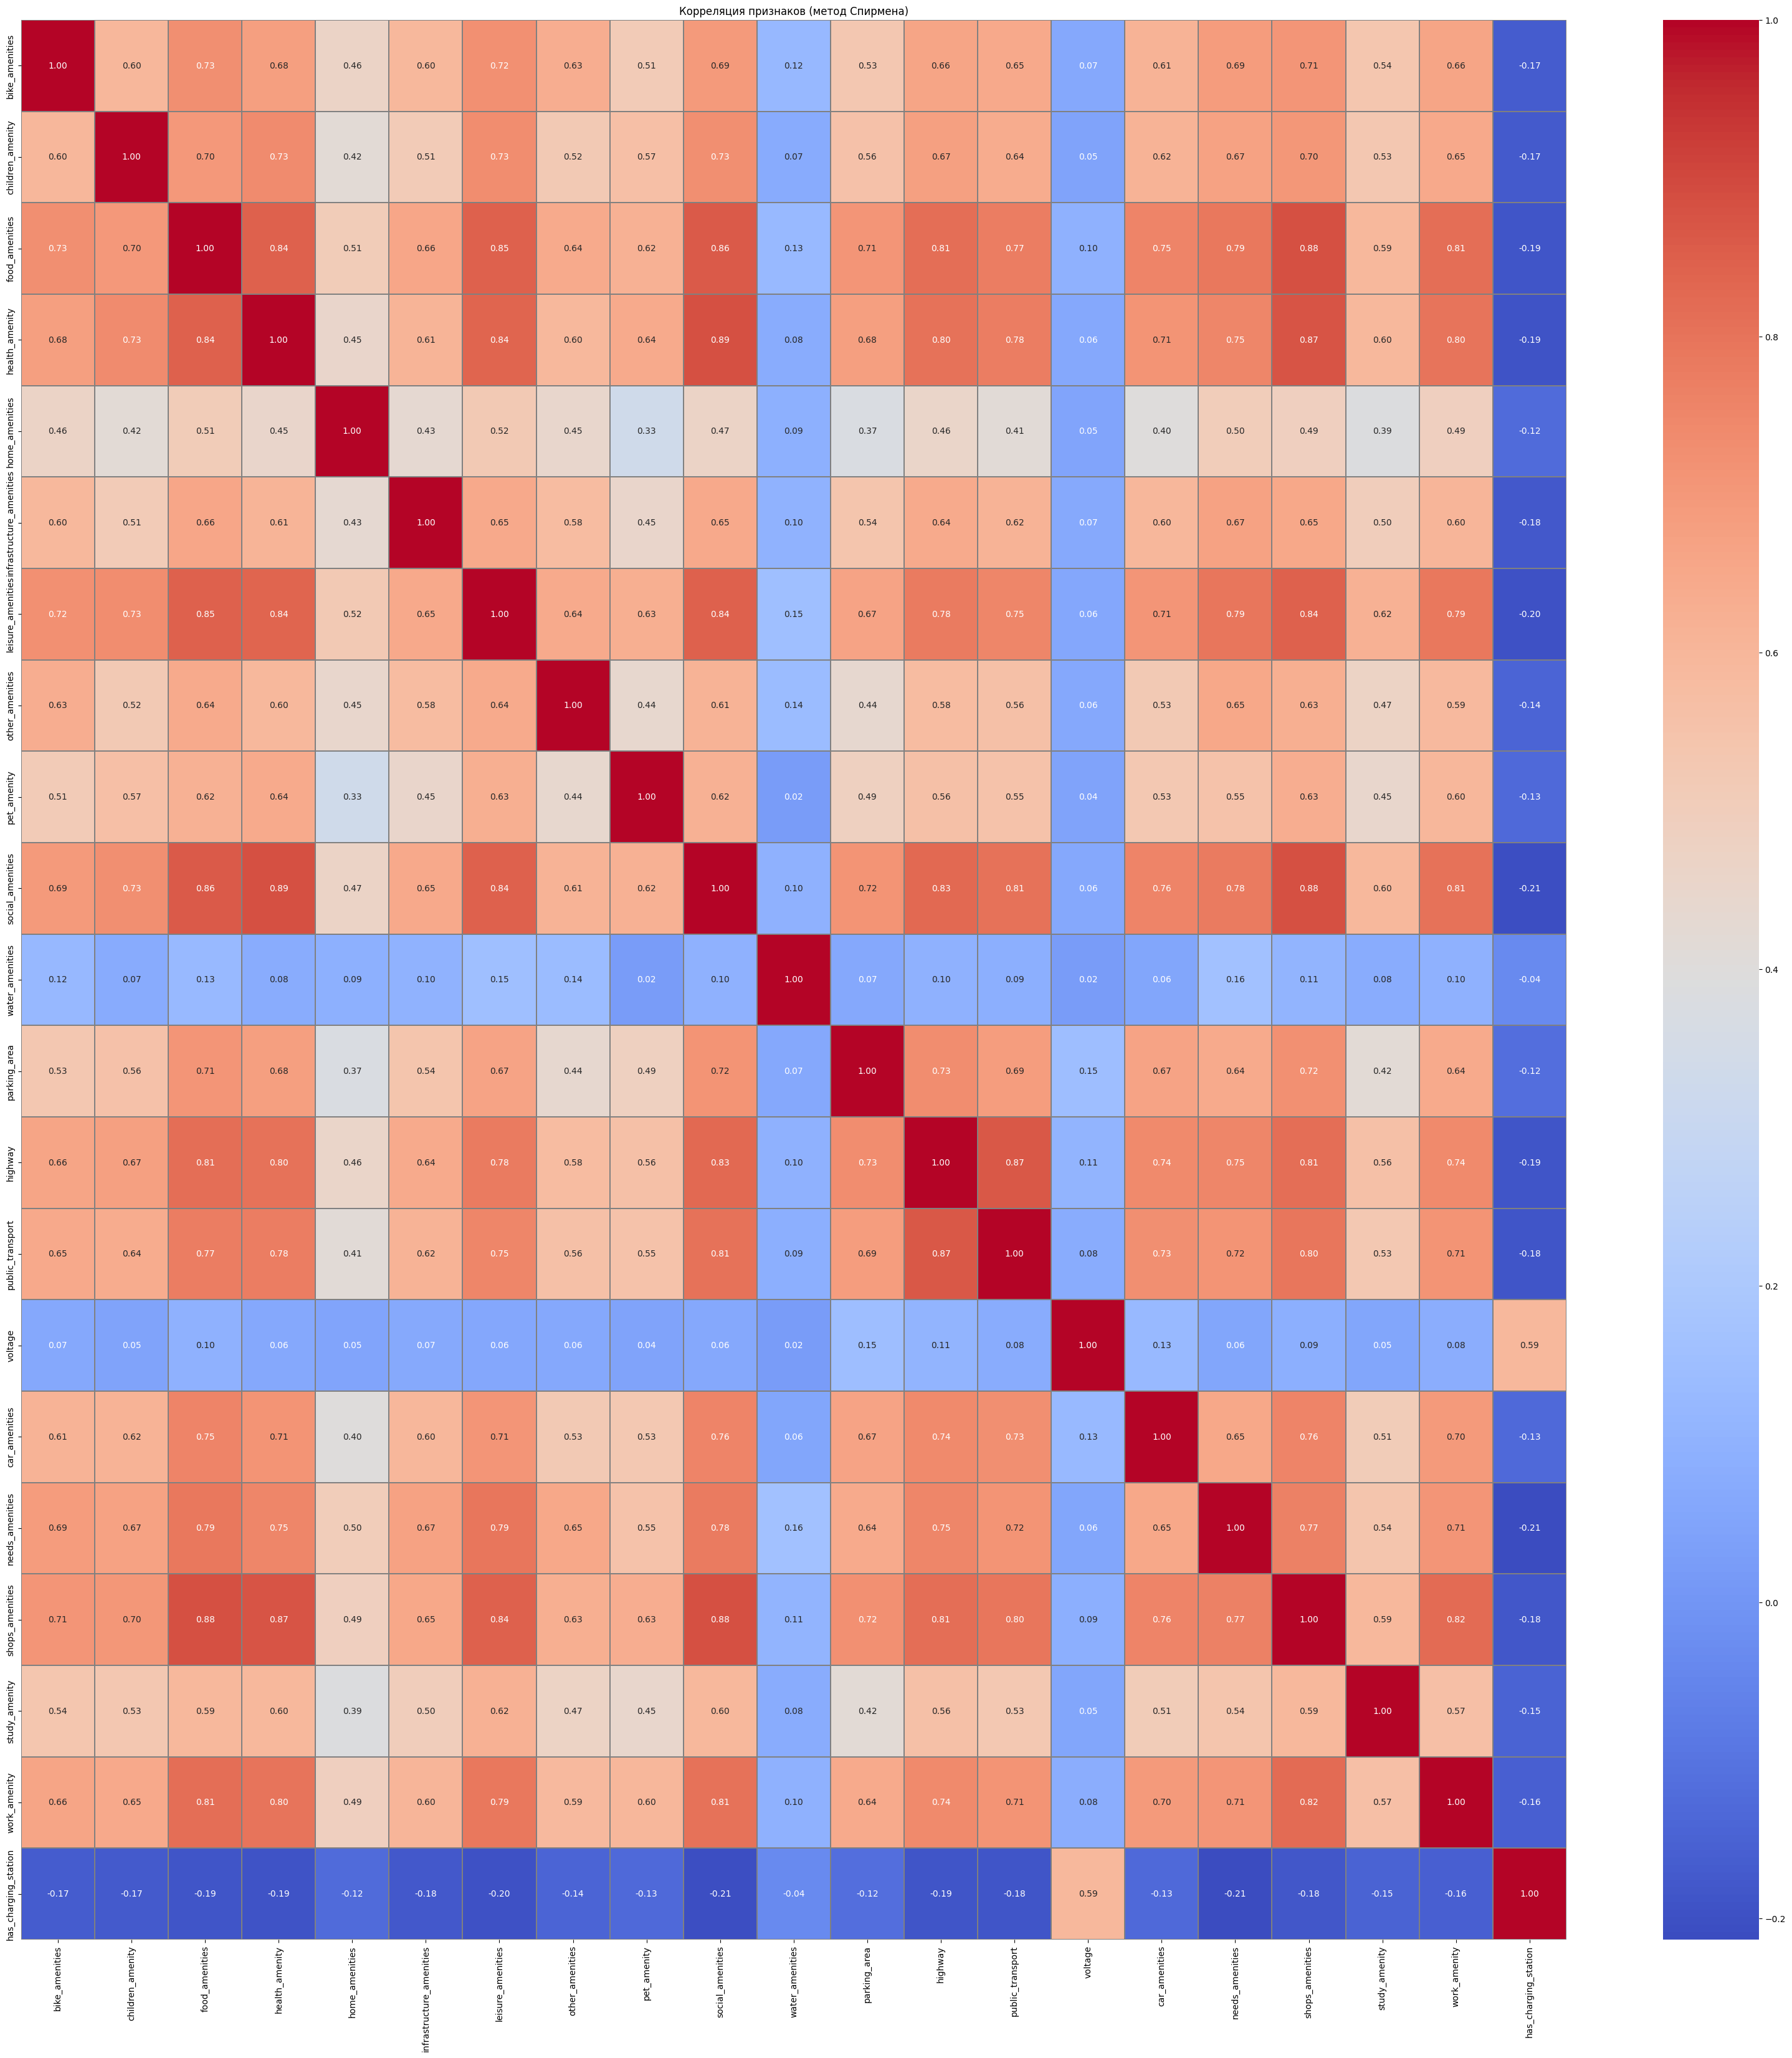

In [55]:
import seaborn as sns

columns_to_plot = ['bike_amenities', 'children_amenity',
       'food_amenities', 'health_amenity', 'home_amenities',
       'infrastructure_amenities', 'leisure_amenities', 'other_amenities',
       'pet_amenity', 'social_amenities', 'water_amenities', 'parking_area',
       'highway',
       'public_transport', 'voltage',
       'car_amenities', 'needs_amenities', 'shops_amenities',
       'study_amenity', 'work_amenity', 'has_charging_station'
]

corr_matrix = df[columns_to_plot].corr(method='spearman', numeric_only=True)

plt.figure(figsize=(40, 40))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1.3, linecolor='gray')


plt.title("Корреляция признаков (метод Спирмена)")
plt.savefig("/Users/dmitrystarukhin/final_diploma_mipt_sumgf/spearman_corr_matrix_msk.pdf", bbox_inches='tight')
plt.show()

In [56]:
df.columns

Index(['h3_index', 'latitude', 'longitude', 'bike_amenities', 'car_amenities',
       'children_amenity', 'food_amenities', 'health_amenity',
       'home_amenities', 'infrastructure_amenities', 'leisure_amenities',
       'needs_amenities', 'other_amenities', 'pet_amenity', 'public_transport',
       'shops_amenities', 'social_amenities', 'study_amenity',
       'water_amenities', 'work_amenity', 'parking_area', 'traffic_count',
       'highway', 'voltage', 'сharger_number', 'has_charging_station',
       'distance_to_center'],
      dtype='object')